In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import h5py
from matplotlib.colors import LogNorm

In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["figure.figsize"] = [10, 10]
mpl.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 35
mpl.rcParams['image.cmap'] = 'viridis'
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.2
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = False
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 35
mpl.rcParams['ytick.labelsize'] = 35
mpl.rcParams['xtick.major.width'] = 4
mpl.rcParams['ytick.major.width'] = 4
mpl.rcParams['xtick.minor.width'] = 4
mpl.rcParams['ytick.minor.width'] = 4
mpl.rcParams['xtick.major.size'] = 20
mpl.rcParams['ytick.major.size'] = 20
mpl.rcParams['xtick.minor.size'] = 12
mpl.rcParams['ytick.minor.size'] = 12
mpl.rcParams['lines.markeredgecolor'] = 'k'
mpl.rcParams['lines.markeredgewidth'] = 0.8
mpl.rcParams['lines.markersize'] = 50
mpl.rcParams['axes.linewidth'] = 4
mpl.rcParams["pdf.use14corefonts"]= True

from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=plt.cm.viridis(np.linspace(0, 1, 7)))

# Galaxy Sample Analysis and Visualization
This routine loads information about the galaxy sample catalog and plots various property histograms, as well as comparing the redshift distribution to the distribution of the comparison catalog

In [ ]:
#------------LOAD GALAXY SAMPLE FROM OUTPUTS-------------------#
data_file = '/Users/skylargrayson/Desktop/testing_RAFIKI_CGM/quickstart_xraydat.hdf5' #can use either the SZ or X-ray output file, they contain the same information
with h5py.File(data_file, 'r') as f:
    sim_name = f['metadata'].attrs['simulation']
    redshift = f['metadata'].attrs['redshift']
    indices = f["metadata"]["galaxy_indices"][:]
    galaxy_redshifts = f["metadata"]["galaxy_redshifts"][:]

In [ ]:
#-------------LOAD GALAXY CATALOG-------------------#
path_to_package_data = '/path/to/downloaded/dataproducts/'

red_shift = {'0.1':'0_1', '0.5':'0_5', '1':'1', '1.0':'1','2':'2','2.0':'2','1.':'1','2.':'2'} #To account for possible names
if redshift not in red_shift:
    raise ValueError(f"Redshift '{redshift}' not recognized. Valid options are: 0.1, 0.5, 1, 2")

path = path_to_package_data+sim_name+'/snap_z'+red_shift[redshift]+'/galaxy_catalog.hdf5'
with h5py.File(path, 'r') as f:

    stell = f['galaxy_properties/stellar_mass'][:]
    dm_mass      = f['galaxy_properties/dm_mass'][:]
    m200c        = f['galaxy_properties/m200c'][:]
    r200c        = f['galaxy_properties/r200c'][:]
    halo       = f['galaxy_properties/m500c'][:]
    rad        = f['galaxy_properties/r500c'][:]
    age          = f['galaxy_properties/age'][:]
    sfr          = f['galaxy_properties/sfr'][:]
    central = f['galaxy_properties/central'][:]

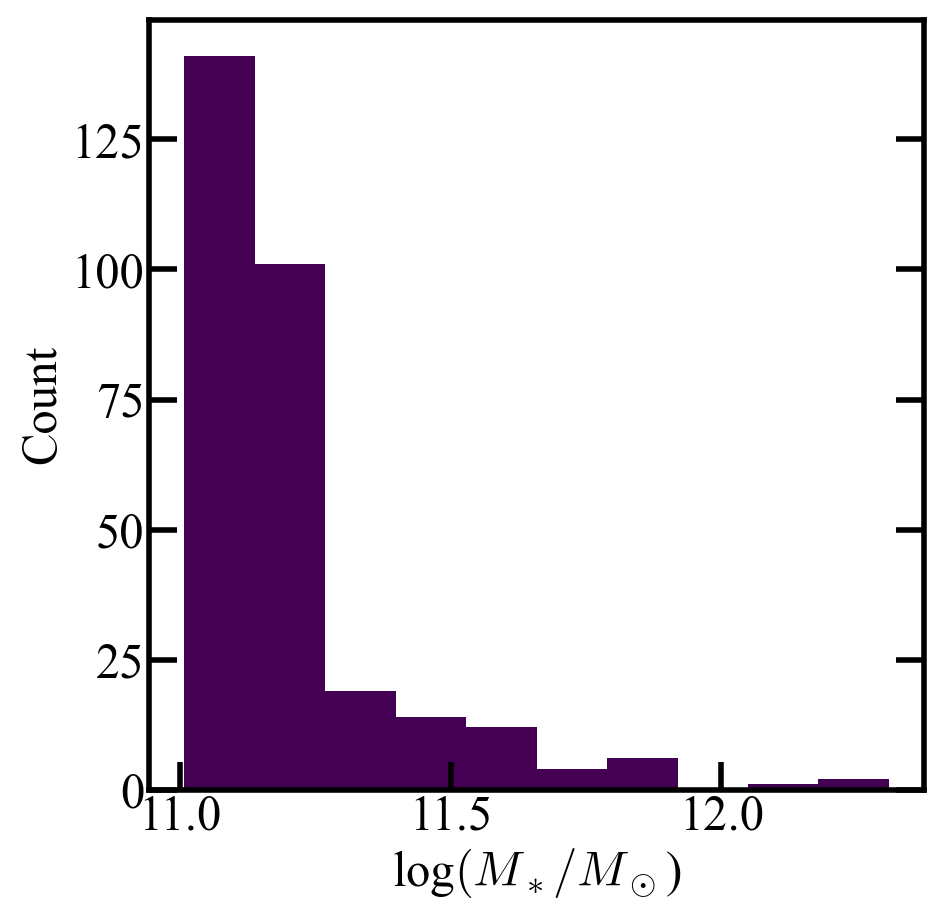

In [44]:
#------------GALAXY STELLAR MASS DISTRIBTUION--------------------#
plt.hist(np.log10(stell)[indices])
plt.ylabel('Count')
plt.xlabel('log$(M_*/M_\odot$)')
plt.savefig('quickstart_stellarmass.png')

/var/folders/kp/32s7fb1928zctcd3kqpfcz9c0000gn/T/ipykernel_58077/3493346128.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.hist(np.log10(halo)[indices])


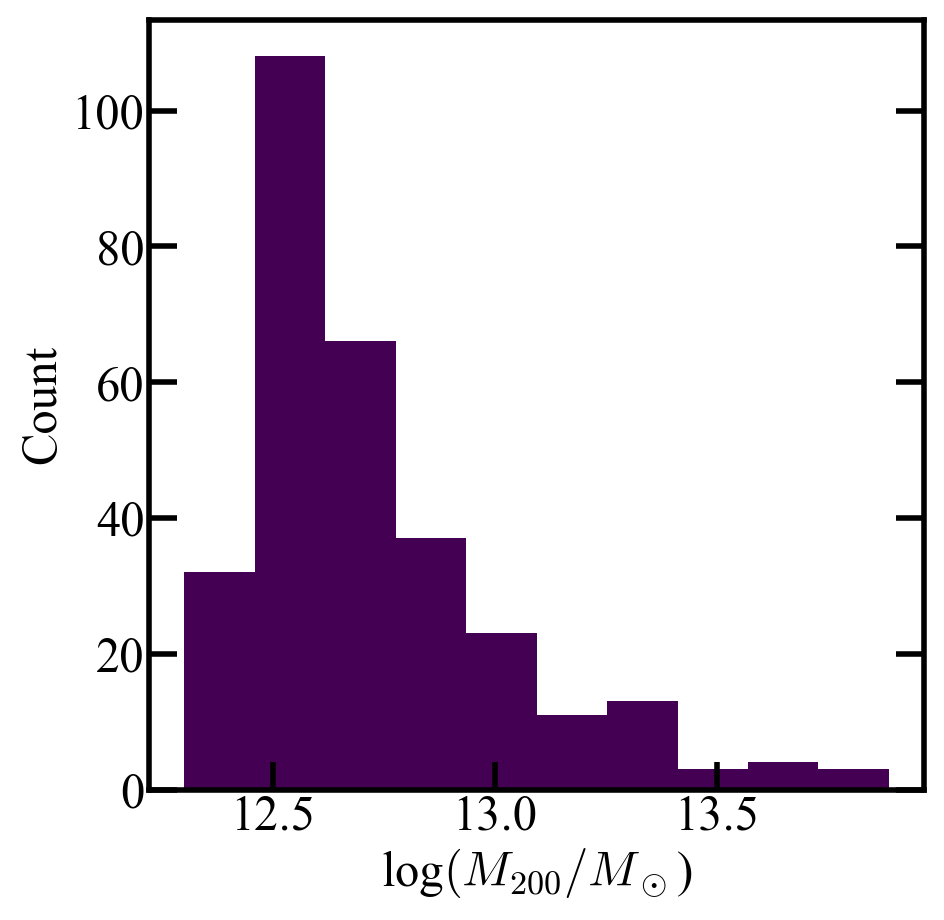

In [45]:
#------------GALAXY HALO MASS DISTRIBTUION--------------------#
plt.hist(np.log10(halo)[indices])
plt.ylabel('Count')
plt.xlabel('log$(M_{200}/M_\odot$)')
plt.savefig('quickstart_halomass.png')

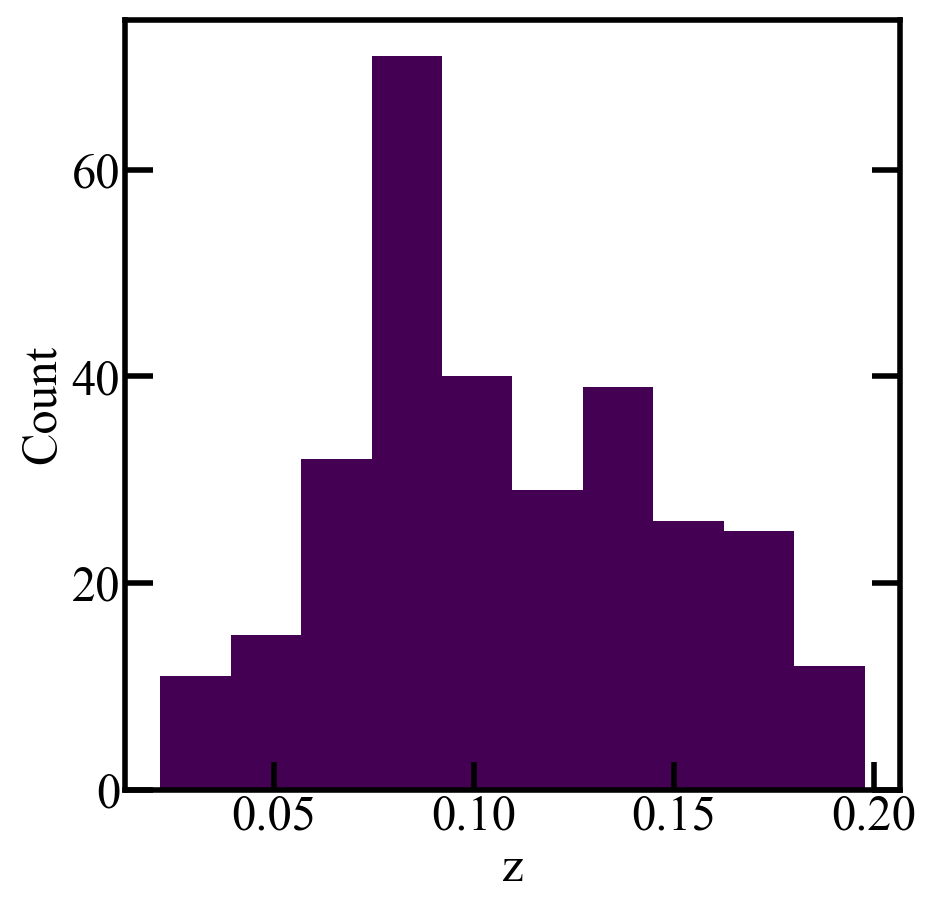

In [46]:
#------------GALAXY REDSHIFT DISTRIBTUION--------------------#
plt.hist(galaxy_redshifts)
plt.ylabel('Count')
plt.xlabel('z')
plt.savefig('quickstart_redshift.png')

## Comparing against the matching catalog

Here we show how to compare the normalized redshift histograms for the selected galaxy sample and the comparison catalog. This format can be adjusted to compare against other properties such as stellar mass

In [ ]:
#------------COMPARE AGAINST OBSERVED REDSHIFT DISTRIBUTION------------#

obs_catalog = '/path/to/downloaded/erosita_comparison.csv' #should match selection.redshift_sampling.observational_catalog in config file
obs_redshifts   = np.array(pd.read_csv(obs_catalog))[:,1].astype(float)
bins = np.linspace(0,0.2,num=20)
obs_hist,bin_edges = np.histogram(obs_redshifts,bins=bins)
obs_hist_norm =obs_hist/np.sum(obs_hist)
sample_hist,bin_edges = np.histogram(galaxy_redshifts, bins=bins)
sample_hist_norm =sample_hist/np.sum(sample_hist)


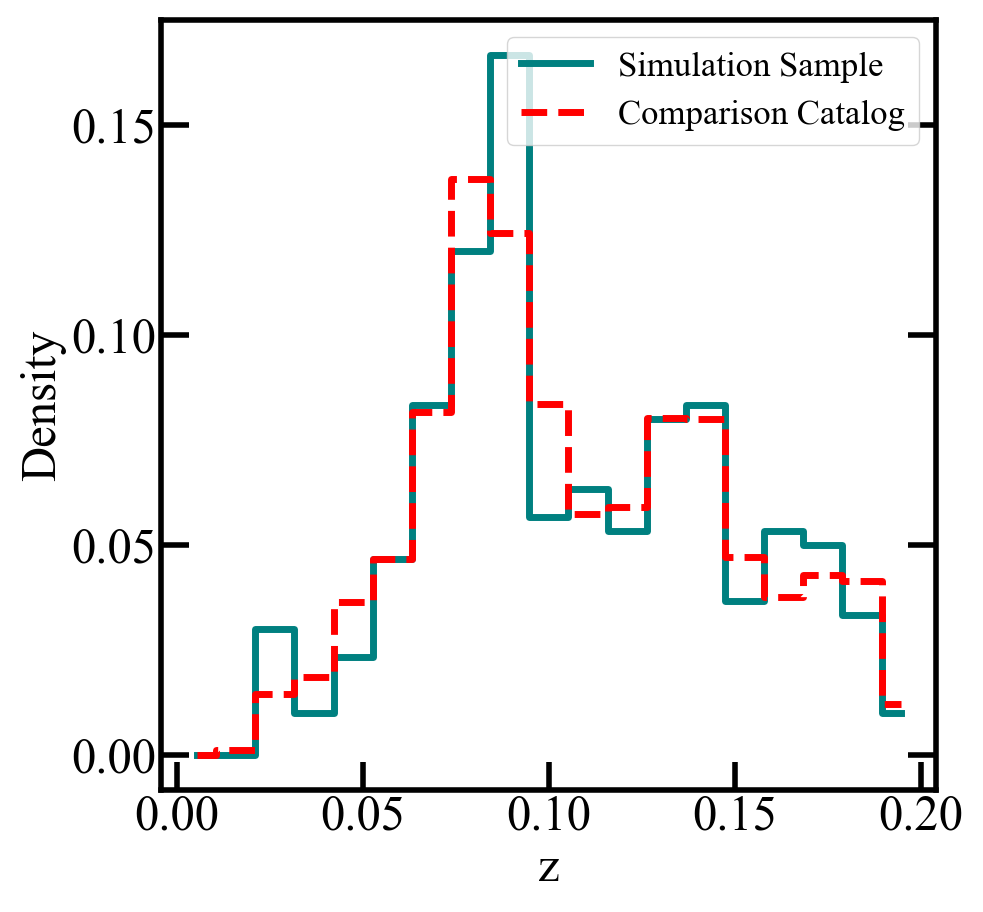

In [ ]:
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])


plt.step(bin_centers, sample_hist_norm, where='mid',
        color='teal', linestyle='-', linewidth=5,label='Simulation Sample')

plt.step(bin_centers, obs_hist_norm, where='mid',
        color='red', linestyle='--', linewidth=5, label='Comparison Catalog')
plt.legend(fontsize=25,loc='upper right')
plt.xlabel('z')
plt.ylabel('Density')
plt.show()
